# OceanDataCatalog | NOC Near-Present Day

## About

This Notebook demonstrates how to use the **OceanDataCatalog** API to explore the [Near-Present-Day](https://noc-msm.github.io/NOC_Near_Present_Day/) global ocean sea-ice simulations developed by the National Oceanography Centre as part of the Atlantic Climate and Environment Strategic Science ([AtlantiS](https://noc.ac.uk/projects/atlantis)) programme.

In [1]:
from OceanDataStore import OceanDataCatalog

* Create an instance of the **OceanDataCatalog** class to access the National Oceanography Centre ocean model Spatio-Temporal Access Catalog (`noc-model-stac`):

In [2]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

* Let's search the Near-Present Day collection for all ocean model outputs including the sea surface temperature (SST) variable `tos_con`:

In [3]:
catalog.search(collection='noc-npd', variable='tos_con')


            * Item ID: noc-npd/npd-eorca1-era5v1/gn_global/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn_global
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd/npd-eorca1-era5v1/gn_global/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn_global
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd/npd-eorca025-era5v1/gn_global/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository contain

* Now, let's take a closer look at the first Item in our search results:

In [6]:
catalog.Items[0]

<Item id=noc-npd/npd-eorca1-era5v1/gn_global/T1y>

* Next, we will open a subset (1980-1990) of the annual-mean SST data from the 1-degree eORCA1 ERA5v1 simulation as an xarray Dataset by using the `open_dataset()` method and specifying start and end date strings:

In [7]:
ds = catalog.open_dataset(id=catalog.Items[0].id,
                          start_datetime='1980-01',
                          end_datetime='1990-12',
                          )
                    
ds

<xarray.Dataset> Size: 9GB
Dimensions:                (time_counter: 11, y: 331, x: 360, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lon                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lat                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    time_centered          (time_counter) datetime64[ns] 88B dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter           (time_counter) datetime64[ns] 88B 1980-07-02 ... 1...
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/73)
    hfds                   (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    berg_latent_heat_flux  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    fsitherm               (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    friver                 (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    e3t                    (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    ...                     ...
    vohfcisf               (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    vowflisf               (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    ttrd_evd_li            (time_counter, deptht, y, x) float32 393MB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    ttrd_qns_li            (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    tossq_con              (time_counter, y, x) float32 5MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>

* Finally, let's create a plot of the time-mean (1980-1990) SST for the globe:

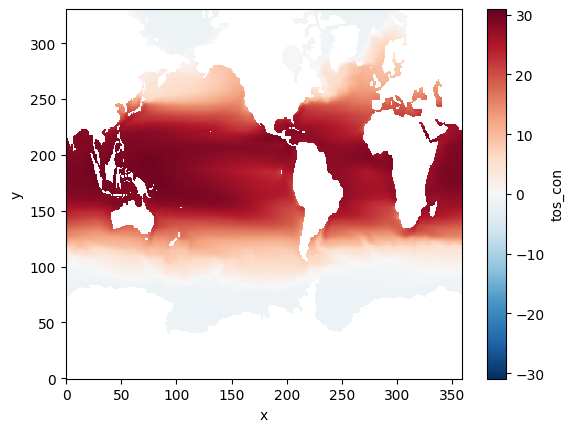

In [8]:
ds['tos_con'].mean(dim='time_counter').plot(cmap='RdBu_r')